In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_xgboost.csv"
)

In [2]:
#serate features and target
X = df.drop(
    columns=["Churn"]
)

y = df["Churn"]

In [3]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [5]:
import shap
# create shap explainer
explainer = shap.TreeExplainer(
    xgb_model
)

In [6]:
#Generate SHAP Values
shap_values = explainer.shap_values(
    X_test
)

FileNotFoundError: [Errno 2] No such file or directory: '../../models/shap_outputs/summary_plots/shap_summary_plot.png'

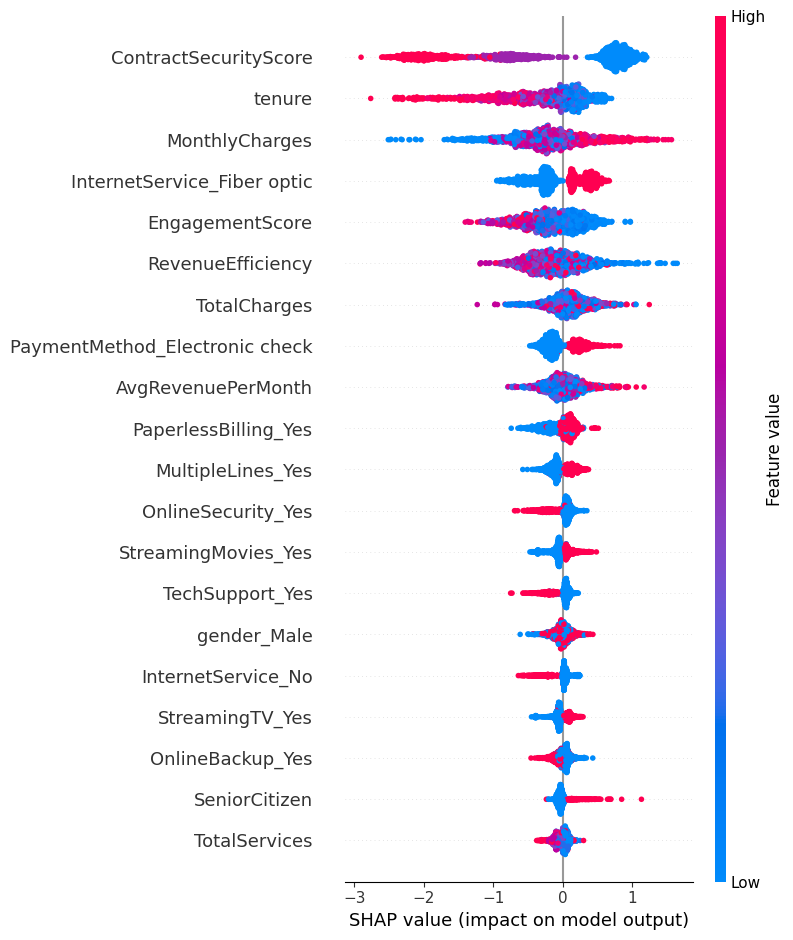

In [8]:
#SHAP Summary Plot
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../../models/shap_outputs/summary_plots/shap_summary_plot.png",
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../models/shap_outputs/summary_plots/shap_bar_plot.png'

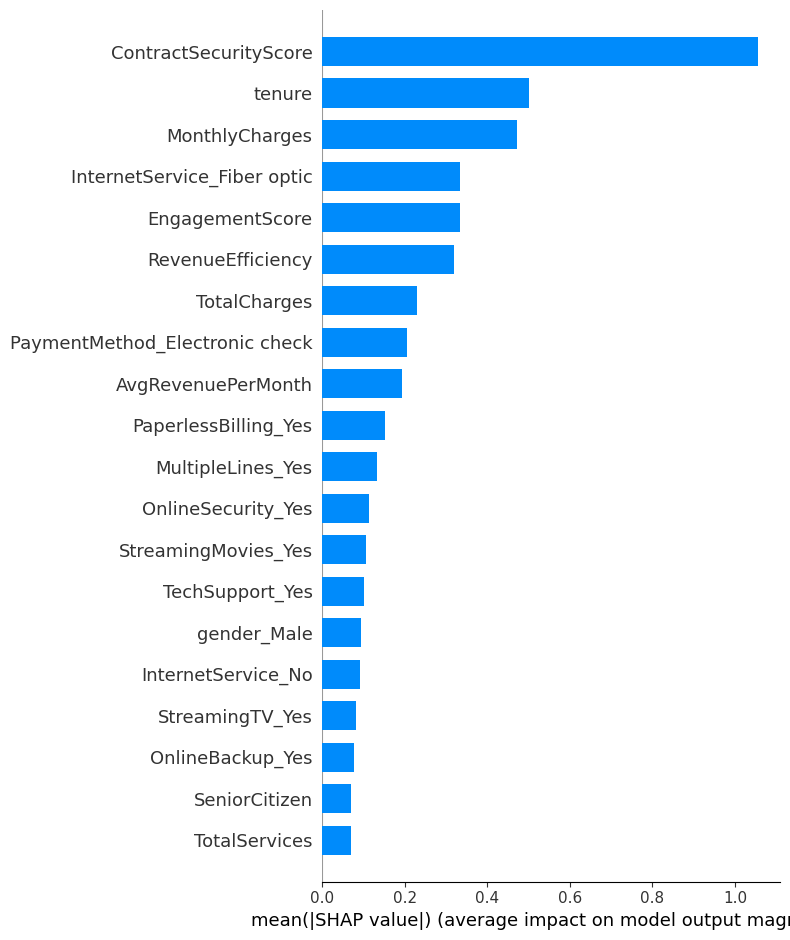

In [9]:
#shap bar plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../../models/shap_outputs/summary_plots/shap_bar_plot.png",
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../models/shap_outputs/dependence_plots/tenure_dependence.png'

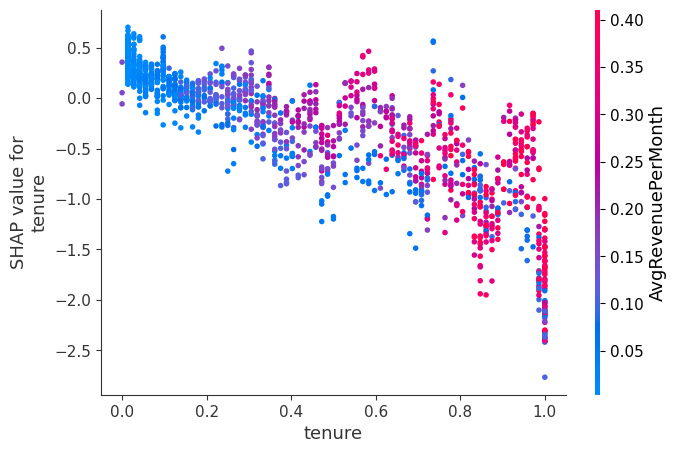

In [10]:
#tenure dependance plot
shap.dependence_plot(
    "tenure",
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../../models/shap_outputs/dependence_plots/tenure_dependence.png",
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../models/shap_outputs/dependence_plots/monthlycharges_dependence.png'

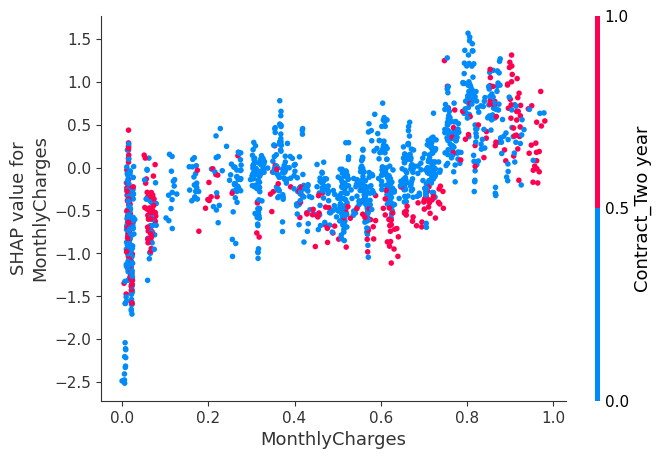

In [11]:
#mointhly charges dependance plot
shap.dependence_plot(
    "MonthlyCharges",
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../../models/shap_outputs/dependence_plots/monthlycharges_dependence.png",
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Calculate SHAP Feature Importance Table
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Importance": np.abs(
        shap_values
    ).mean(axis=0)
})

In [13]:
#Sort Importance
feature_importance = feature_importance.sort_values(
    by="SHAP_Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,SHAP_Importance
8,ContractSecurityScore,1.056482
1,tenure,0.500132
2,MonthlyCharges,0.472335
16,InternetService_Fiber optic,0.333600
6,EngagementScore,0.332986
7,RevenueEfficiency,0.318174
3,TotalCharges,0.229334
34,PaymentMethod_Electronic check,0.204988
4,AvgRevenuePerMonth,0.193884
32,PaperlessBilling_Yes,0.152629


In [ ]:
#View Top Features
feature_importance.head(20)

,Feature,SHAP_Importance
8,ContractSecurityScore,1.056482
1,tenure,0.500132
2,MonthlyCharges,0.472335
16,InternetService_Fiber optic,0.333600
6,EngagementScore,0.332986
7,RevenueEfficiency,0.318174
3,TotalCharges,0.229334
34,PaymentMethod_Electronic check,0.204988
4,AvgRevenuePerMonth,0.193884
32,PaperlessBilling_Yes,0.152629
